# Exercise 1
Minimize $y = i^2 - 4i$ where i is a variable that can take on integer values between -5 and 5 (inclusive).

## Create Model

In [3]:
# required imports
from dwave.optimization import Model
from dwave.system import LeapHybridNLSampler

# create blank model
model = Model()


# add in i variable
i = model.integer(lower_bound=-5, upper_bound=5)

# add in constant of 4
c = model.constant(4)

# create $y = i^2 - 4i$
y = i ** 2 - c * i

# minimize y
model.minimize(y)

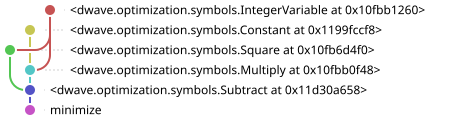

In [4]:
# Display nodes
import dagviz
from IPython.display import display, SVG
G = model.to_networkx() 
r = dagviz.render_svg(G)

# Display the SVG content directly in Jupyter Lab
display(SVG(r))

In [5]:
# The following image represents the DAG of the model of minimize $y = i^2 - 4i$
from IPython.display import Image
from IPython.core.display import HTML
Image(url="https://docs.dwavequantum.com/en/latest/_images/simple_polynomial_DAG.png")

## Solve Problem
Send the NL Model to the LeapHybridNLSampler

In [6]:
# hint-use LeapHybridNLSampler in dwave.system
sampler = LeapHybridNLSampler()
sampler.sample(model, label="NL Solver Basic")

<Future at 0x106c041d0 state=running>

## Check Results

In [10]:
# Check the objective and value of i
with model.lock():
    print("Objective:", model.objective.state(0))
    print("Value of i:", i.state(0))

Objective: -4.0
Value of i: 2.0
